# OpenUniverse — error de observación Roman desde el SED (`galsim.roman`)

Toma la magnitud verdadera por banda de un transiente del `snana_<healpix>.hdf5` de OpenUniverse
(`mag_<R,Z,Y,J,H,F,K>` sobre la grilla `mjd` del modelo), la **muestrea a la cadencia real del survey**
(HLTDS Wide/Deep, nearest-MJD) y le estima el **error fotométrico por época** con la receta de ruido de
`galsim.roman` (sky + thermal + dark + read sobre la NEA del PSF, más el Poisson de la fuente).
De ahí salen SNR, barra de error y el flag de detección S/N ≥ 5.

El hdf5 **no** trae error/NEA/flux-calib: todo eso se deriva acá desde `galsim.roman`. Es la misma
receta validada en `openuniverse_route_a_lightcurves.ipynb`, aquí aplicada a la curva verdadera del SED.

Parámetros clave en la celda de setup: `TIER` ("wide"/"deep") fija filtros, exposición total por época
(`EXPOSURE_TIME`) y cadencia (`CADENCE_DAYS`). El criterio del pipeline son las **primeras 4 épocas
desde la primera detección S/N ≥ 5**.


In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import galsim
import galsim.roman as roman

# Receta de error fotométrico Roman (fuente única de verdad): constantes y funciones se importan de
# roman_photometry.py en vez de redefinirlas aquí, para no desincronizar las 3 copias del pipeline.
from roman_photometry import (
    SNR_DETECTION, ZP_JITTER_SIGMA,
    EXPOSURE_TIME_BY_TIER, BASE_CADENCE_DAYS, TIER_ANCHOR_BAND, ALL_BANDS_BY_WAVELENGTH,
    HLTDS_FIELD_CENTER, HLTDS_FIELDS_BY_TIER,
    field_center_for_tier, cadence_schedule,
)

# Para esta validación el hdf5 ya está descargado en el scratchpad de la sesión.
# En la corrida por healpix será openuniverse_cache/snana_<healpix>.hdf5.
HDF5_PATH = "/Users/bhianca/Kilonova/data/openuniverse/snana_10307_full.hdf5"
CATALOG_PATH = "/Users/bhianca/Kilonova/data/openuniverse/snana_10307.parquet"

# Las constantes del survey (exposición por tier/época, cadencia, campos HLTDS, mapeo HLTDS->galsim,
# elección aleatoria de campo) viven en roman_photometry.py — ver ahí la documentación de cada una.

TIER = "deep"  # "wide" | "deep" — define filtros, exposición y cadencia
EXPOSURE_TIME = EXPOSURE_TIME_BY_TIER[TIER]
ANCHOR_BAND = TIER_ANCHOR_BAND[TIER]
# Campo del tier: elección aleatoria entre los campos válidos, semilla fija -> reproducible por corrida.
FIELD_SEED = 0
FIELD_NAME, FIELD_CENTER_RA, FIELD_CENTER_DEC = field_center_for_tier(TIER, np.random.default_rng(FIELD_SEED))

# Bandas del tier, ordenadas por longitud de onda. La letra del hdf5 (mag_<X>) es la inicial de la banda.
BANDS_BY_WAVELENGTH = [band for band in ALL_BANDS_BY_WAVELENGTH if band in EXPOSURE_TIME]

# Cadencia efectiva por banda (referencia / zoom): anchor cada 5 d, las otras cada 10 d.
CADENCE_DAYS = {band: (BASE_CADENCE_DAYS if band == ANCHOR_BAND else 2 * BASE_CADENCE_DAYS)
                for band in BANDS_BY_WAVELENGTH}

BAND_WAVELENGTH_MICRON = {"R062": 0.62, "Z087": 0.87, "Y106": 1.06, "J129": 1.29,
                          "H158": 1.58, "F184": 1.84, "K213": 2.13}
BAND_COLOR = {band: plt.cm.turbo((wavelength - 0.55) / 1.7)
              for band, wavelength in BAND_WAVELENGTH_MICRON.items()}

GENTYPE_LABEL = {10: "SN Ia", 12: "SN Iax", 21: "SN Ib", 26: "SN Ic", 32: "SN II",
                 40: "SLSN-I", 42: "TDE", 50: "KN", 57: "PISN-H", 58: "PISN-He", 99: "FIXMAG"}


def plot_lightcurve_with_error(photometry, title="", ax=None):
    own_axis = ax is None
    if own_axis:
        figure, ax = plt.subplots(figsize=(9, 5))
    # Eje de tiempo unificado con el pipeline y el dataloader: días desde la 1ª detección S/N>=5.
    present_bands = [band for band in BANDS_BY_WAVELENGTH if (photometry["band"] == band).any()]
    # Cada visita (cada 5 d) observa 3 de los 5 filtros del tier; los 2 NO observados se marcan con un
    # cuadrado en su fila (arriba). Así cada época muestra siempre 5 símbolos = los 5 filtros del tier:
    # 3 con dato (○ detección / ▽ límite) + 2 cuadrados (no observado en esa visita). Valida la cadencia.
    base_visits = np.sort(photometry["days_since_detection"].unique())
    epoch_transform = ax.get_xaxis_transform()  # x en datos, y en fracción de ejes
    for index, band in enumerate(present_bands):
        band_rows = photometry[photometry["band"] == band]
        color = BAND_COLOR[band]
        detections = band_rows[band_rows["detected"]]
        upper_limits = band_rows[~band_rows["detected"]]
        if len(detections) > 0:
            ax.errorbar(detections["days_since_detection"], detections["mag_observed"], yerr=detections["mag_err"],
                        fmt="o", ms=4, color=color, ecolor=color, elinewidth=0.6,
                        capsize=0, mec="k", mew=0.3)
        if len(upper_limits) > 0:
            ax.scatter(upper_limits["days_since_detection"], upper_limits["mag_limit_5sigma"], marker="v",
                       s=22, color=color, edgecolor="k", linewidth=0.3, alpha=0.45)
        not_observed = np.setdiff1d(base_visits, band_rows["days_since_detection"].to_numpy())
        if len(not_observed) > 0:
            y_rug = 0.985 - 0.03 * index
            ax.scatter(not_observed, np.full(len(not_observed), y_rug), marker="s", s=14,
                       color=color, edgecolor="k", linewidth=0.2, transform=epoch_transform, zorder=5)
            ax.text(0.004, y_rug, band, transform=ax.transAxes, va="center", ha="left",
                    fontsize=6, color=color)

    first = photometry[photometry["detected"]]["days_since_detection"]
    if len(first) > 0:
        ax.axvline(first.min(), color="grey", ls=":", lw=1.0)
    ax.invert_yaxis()
    ax.set_xlabel("días desde 1ª detección")
    ax.set_ylabel("AB mag")
    ax.set_title(title)
    band_handles = [plt.Line2D([], [], marker="o", ls="", color=BAND_COLOR[band], label=band)
                    for band in present_bands]
    symbol_handles = [plt.Line2D([], [], marker="o", ls="", color="0.4", label="detección (S/N≥5)"),
                      plt.Line2D([], [], marker="v", ls="", color="0.4", label="límite 5σ"),
                      plt.Line2D([], [], marker="s", ls="", color="0.4", label="no observada (cadencia)")]
    ax.legend(handles=band_handles + symbol_handles, fontsize=7, ncol=2, loc="best")
    if own_axis:
        plt.tight_layout()
        plt.show()


## La receta de ruido — la idea de Hourglass aplicada a OpenUniverse

El error fotométrico de cada época sale de **una sola ecuación**: la ecuación CCD estándar
(Howell 1989, eq. 14), la misma con la que reproducimos el `fluxcal_err` de Hourglass (mediana
$\sigma_{\text{pred}}/\sigma_{\text{real}}=0.986$). En espacio de cuentas (electrones), la varianza
de una medición de fuente puntual es

$$\sigma^2(F) \;=\; \underbrace{F_{\text{fuente}}}_{\text{Poisson de la fuente}} \;+\; \underbrace{n_{\text{pix}}\,\big(B_{\text{sky}} + B_{\text{thermal}} + B_{\text{dark}} + \sigma_{\text{read}}^2\big)}_{\text{fondo + lectura}} \qquad [e^{-2}]$$

con $n_{\text{pix}} = \mathrm{NEA}$, el **número equivalente de píxeles** de la PSF (King 1983; Naylor 1998
para extracción óptima). Esto es exactamente lo que implementan las dos celdas siguientes:
`NOISE_FLOOR_VARIANCE` es el segundo término (el fondo, fijo por banda) y `flux_electrons` es el primero.

### Por qué es "la misma idea" que Hourglass, pero más limpia

Hourglass entrega su fotometría en `fluxcal` (convención SNANA, ZP=27.5), así que su receta tiene que
**puentear** cuentas físicas ↔ `fluxcal` con el factor $\text{flux\_calibrated}(zp)=10^{(27.5-zp)/2.5}$:

| | término de fuente | término de fondo |
|---|---|---|
| **Hourglass** (`fluxcal`) | $\text{flux\_calibrated}(zp)\cdot F_{\text{sim}}$ — lineal en el puente | $\mathrm{NEA}\,(\sigma_{\text{sky}}^2+\sigma_{\text{read}}^2)\cdot\text{flux\_calibrated}(zp)^2$ — **cuadrático** en el puente |
| **Este notebook** (`galsim.roman`, $e^-$) | $F_{\text{fuente}}$ — el conteo mismo | $\mathrm{NEA}\,(B_{\text{sky}}+B_{\text{thermal}}+B_{\text{dark}}+\sigma_{\text{read}}^2)$ |

La asimetría lineal/cuadrático de Hourglass es **sólo el cambio de unidades** $e^{-2}\to\text{fluxcal}^2$
(el término de fuente lleva un factor de Fano $\alpha$, el de fondo lleva $\alpha^2$ de propagación lineal).
Acá **nunca salimos de electrones**: la varianza Poisson de $N$ electrones *es* $N$, sin factor puente
y sin Fano explícito. Por eso `flux_error = np.sqrt(flux_electrons + noise_floor)` es la traducción
directa de la ecuación de arriba.

Ventaja práctica de quedarnos en `galsim.roman`: **cada número es trazable a su fuente** — `getSkyLevel`,
`thermal_backgrounds`, `dark_current`, el `zeropoint` AB del bandpass y la NEA salida de `getPSF`. El
único término que tomamos del paper (no de galsim) es el read noise, por la razón de abajo.

### Cómo entra el tiempo de exposición (los nuevos valores del HLTDS)

`EXPOSURE_TIME_BY_TIER` trae los tiempos **totales por época**. Cada término del fondo depende de la
exposición $t$, y eso está puesto en el cálculo de `NOISE_FLOOR_VARIANCE`:

- **sky, thermal, dark** → **crecen con $t$**: son tasas de electrones acumulando señal. `getSkyLevel(exptime=t)`,
  `thermal_backgrounds·t`, `dark_current·t`. Más exposición ⇒ más fondo acumulado.
- **read noise** → **decrece con $t$** (Rose et al. 2025, **eq. 9**), por el muestreo *up-the-ramp*:

$$\sigma_{\text{read}} = \sqrt{\;\sigma^2_{\text{floor}} + \sigma^2\,\frac{n-1}{n(n+1)}\;}, \qquad n = \frac{t_{\text{exp}}}{3.04\,\text{s}},\quad \sigma^2_{\text{floor}}=25,\quad \sigma^2 = 12\cdot 16^2 = 3072 \;\;[e^{-2}]$$

  Los detectores NIR de Roman se leen de forma **no-destructiva cada 3.04 s**, así que una época de
  $t_{\text{exp}}$ acumula $n=t_{\text{exp}}/3.04$ lecturas. Al ajustar la pendiente sobre $n$ lecturas el
  read noise efectivo **baja** (el término $\frac{n-1}{n(n+1)}\to\frac1n\to0$) y **satura en el piso**
  $\sqrt{25}=5\,e^-$. Con tus nuevos tiempos: ~5.5 $e^-$ (F184, 1636 s) hasta ~13 $e^-$ (R062, 60 s).

> **Cuidado con el denominador.** La eq. 9 lleva $n(n+1)$ en el denominador, **no** $(n+1)$. Verificación:
> F184 DEEP a la exposición vieja (900 s, $n=296$) da $\sqrt{25+3072\cdot 295/(296\cdot 297)}=\mathbf{5.94\,e^-}$,
> idéntico al Table 3 del paper (F = 5.942). Con $(n+1)$ a secas saldría ~55 $e^-$ (10× de más). Esto
> reemplaza al `roman.read_noise` estático de galsim, que desconoce los tiempos del HLTDS revisado.

### El NEA y el jitter del zeropoint (Hourglass eq. 8) — *modelado*

El NEA y el throughput **cambian con la posición en el plano focal**. En vez de variar la PSF fila por fila,
Hourglass **fija el NEA por banda** (mediana mejor/peor FOV, Table 3) y **absorbe** esa variación FOV-a-FOV
en un **scatter gaussiano de $\sigma=0.15$ mag sobre el zeropoint** de cada observación
($\text{ZP\_AVG} = \text{ZP} + 2.5\log_{10}t + \mathcal{N}(0,0.15)$). Replicamos exactamente eso:

- el NEA sale **una vez por banda** de `getPSF` en el centro del campo (decisión deliberada, igual que Hourglass);
- cada época recibe un **jitter** $\delta\sim\mathcal{N}(0,\texttt{ZP\_JITTER\_SIGMA})$, `ZP_JITTER_SIGMA=0.15 mag`,
  sumado a su zeropoint antes de convertir `mag_true → flux_electrons`. Un $\delta$ positivo = posición del FOV
  más sensible = más electrones = mayor SNR. La semilla del jitter se fija **por objeto** (reproducible) e
  independiente entre épocas/bandas (cada visita cae en otra parte del plano focal). `ZP_JITTER_SIGMA=0` lo apaga.

El jitter se aplica al zeropoint de la **fuente** (el término que mueve la SNR); el fondo en electrones
(`getSkyLevel` etc.) es absoluto y no depende de ese zeropoint, así que no se toca.


In [2]:
# Calibración Roman desde roman_photometry.py (que la deriva de galsim.roman): zeropoint AB, NEA,
# read noise eq.9 y el piso de ruido por banda. El hdf5 no aporta nada de esto. La constante
# ZP_JITTER_SIGMA y read_noise_electrons/PSF_NEA_PIX se importan; no se redefinen aquí.
from roman_photometry import (
    PSF_NEA_PIX, ROMAN_ZEROPOINT, COLLECTING_AREA_CM2,
    read_noise_electrons, build_tier_constants,
    source_flux_electrons, flux_error_electrons, limiting_magnitude_5sigma,
)

# Constantes del tier (bandas, zeropoint, piso de ruido NEA-pesado) derivadas en el módulo a la
# exposición del TIER y el campo de FIELD_SEED. Es exactamente la misma receta del pipeline.
_tier_constants = build_tier_constants(TIER, field_seed=FIELD_SEED)
NOISE_FLOOR_VARIANCE = _tier_constants["noise_floor_variance"]
READ_NOISE_BY_BAND = {band: read_noise_electrons(EXPOSURE_TIME[band]) for band in BANDS_BY_WAVELENGTH}

pd.DataFrame({"read_noise_e": pd.Series(READ_NOISE_BY_BAND),
              "noise_floor_variance_e2": pd.Series(NOISE_FLOOR_VARIANCE)})


,read_noise_e,noise_floor_variance_e2
Z087,8.478636,1099.372099
Y106,7.490976,1652.906757
J129,7.404273,2009.190961
H158,6.849515,3162.985676
F184,5.539602,13208.567471


In [3]:
def read_true_lightcurve(object_id, hdf5=None, hdf5_path=HDF5_PATH):
    """Curva de luz verdadera (sin ruido) de un objeto: mag_<banda>(mjd) sobre TODA la grilla del
    modelo del hdf5, solo para las bandas del TIER, en formato largo. Descarta mag >= 99.
    La letra del dataset hdf5 (mag_R, mag_Z, ...) es la inicial de la banda galsim (R062 -> R).
    `hdf5` permite pasar un File ya abierto (para escanear muchos objetos sin reabrirlo)."""
    handle = hdf5 if hdf5 is not None else h5py.File(hdf5_path, "r")
    try:
        group = handle[str(object_id)]
        mjd = group["mjd"][:]
        rows = []
        for band in BANDS_BY_WAVELENGTH:
            magnitude = group["mag_" + band[0]][:]
            valid = np.isfinite(magnitude) & (magnitude < 99)
            rows.append(pd.DataFrame({"object_id": object_id, "mjd": mjd[valid],
                                      "band": band, "mag_true": magnitude[valid]}))
    finally:
        if hdf5 is None:
            handle.close()
    return pd.concat(rows, ignore_index=True)


def resample_to_cadence(true_lightcurve):
    """Pasa de la grilla densa del modelo a las ÉPOCAS DE OBSERVACIÓN del survey: visitas base cada
    BASE_CADENCE_DAYS sobre la ventana del modelo, repartidas por banda con roman_photometry.cadence_schedule
    (anchor en todas, las otras 4 en 2 pares intercalados). Toma la mag del MJD del modelo MÁS CERCANO
    (nearest, no interpola: la grilla <=1 d es mucho más fina que la cadencia 5-10 d). El MJD absoluto se
    mantiene solo como eje interno para el nearest-lookup; el eje de salida es days_since_detection."""
    window_start = true_lightcurve["mjd"].min()
    window_end = true_lightcurve["mjd"].max()
    base_epochs = np.arange(window_start, window_end + 1e-9, BASE_CADENCE_DAYS)
    schedule = cadence_schedule(base_epochs, BANDS_BY_WAVELENGTH, ANCHOR_BAND)
    rows = []
    for band in BANDS_BY_WAVELENGTH:
        band_rows = true_lightcurve[true_lightcurve["band"] == band]
        if len(band_rows) == 0:
            continue
        model_mjd = band_rows["mjd"].to_numpy()
        model_mag = band_rows["mag_true"].to_numpy()
        epochs = schedule[band]
        epochs = epochs[(epochs >= model_mjd.min()) & (epochs <= model_mjd.max())]
        nearest = np.abs(model_mjd[None, :] - epochs[:, None]).argmin(axis=1)
        rows.append(pd.DataFrame({"object_id": band_rows["object_id"].iloc[0],
                                  "mjd": epochs, "band": band, "mag_true": model_mag[nearest]}))
    return pd.concat(rows, ignore_index=True)


def estimate_observation_error(photometry, plot=False):
    """Estima el error fotométrico Roman de cada (época, banda) con la receta de roman_photometry:
    mag_true -> flux en electrones -> sigma_flux (Poisson fuente + piso de ruido NEA) -> SNR.
    Usa el tiempo de exposición TOTAL por época del tier (EXPOSURE_TIME). Agrega days_since_detection
    (cero en la 1ª detección S/N>=5; si no hay detección, relativo a la 1ª visita) como eje de tiempo,
    misma convención que el early_windows_{tier}.parquet del pipeline.

    Jitter FOV del zeropoint (Rose et al. 2025, eq. 8): a cada época se le suma un delta
    ~ N(0, ZP_JITTER_SIGMA) [mag] sobre el zeropoint de su banda, modelando que la PSF/throughput
    cambian con la posición en el plano focal. Semilla por objeto -> reproducible; independiente
    entre épocas/bandas. El jitter mueve la calibración de la FUENTE (y por tanto la SNR); el fondo
    en electrones es absoluto y no se toca."""
    photometry = photometry.copy()
    base_zeropoint = photometry["band"].map(ROMAN_ZEROPOINT).to_numpy()
    object_seed = int(photometry["object_id"].iloc[0])
    jitter_random = np.random.default_rng(object_seed)
    zeropoint_jitter = jitter_random.normal(0.0, ZP_JITTER_SIGMA, size=len(photometry))
    zeropoint = pd.Series(base_zeropoint + zeropoint_jitter, index=photometry.index)
    exposure = photometry["band"].map(EXPOSURE_TIME)
    noise_floor = photometry["band"].map(NOISE_FLOOR_VARIANCE)

    flux_electrons = source_flux_electrons(photometry["mag_true"], exposure, zeropoint)
    flux_error = flux_error_electrons(flux_electrons, noise_floor)
    photometry["zeropoint"] = zeropoint
    photometry["flux_electrons"] = flux_electrons
    photometry["flux_error"] = flux_error
    photometry["snr"] = flux_electrons / flux_error
    photometry["mag_err"] = 1.0857 / photometry["snr"]
    photometry["detected"] = photometry["snr"] >= SNR_DETECTION
    # Para no-detecciones: límite 5sigma (la fuente es más débil que esto). Usa el zeropoint con jitter
    # para que el límite sea consistente con la calibración de esa época.
    photometry["mag_limit_5sigma"] = limiting_magnitude_5sigma(flux_error, exposure, zeropoint)
    photometry["mag_observed"] = photometry["mag_true"]
    # Eje de tiempo unificado: días desde la 1ª detección S/N>=5 (cero en esa visita).
    detected_mjd = photometry.loc[photometry["detected"], "mjd"]
    reference_mjd = detected_mjd.min() if len(detected_mjd) > 0 else photometry["mjd"].min()
    photometry["days_since_detection"] = photometry["mjd"] - reference_mjd
    return photometry


def build_photometry(object_id, hdf5=None):
    """hdf5 -> curva verdadera -> épocas a cadencia real (anchor + 2, nearest-MJD) -> error Roman."""
    return estimate_observation_error(resample_to_cadence(read_true_lightcurve(object_id, hdf5=hdf5)))


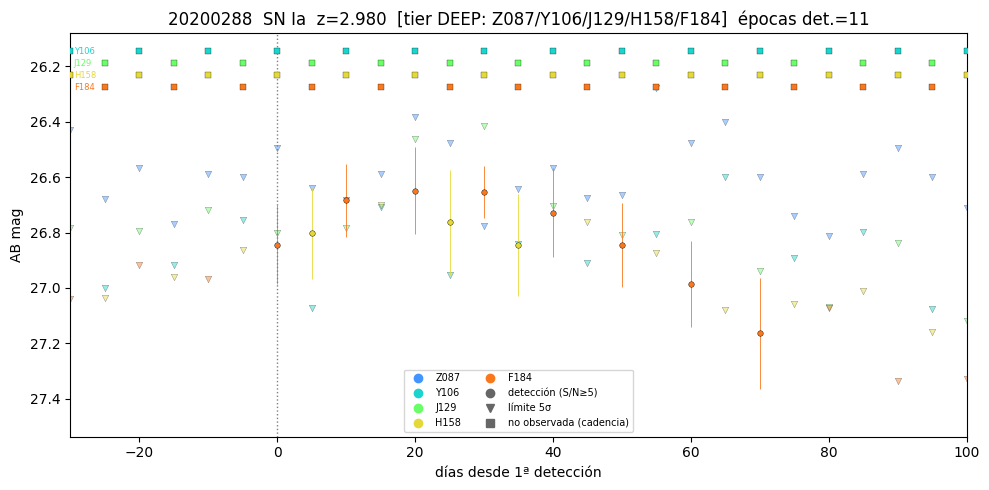

In [4]:
def select_object(transients, select="high_z", min_detected_epochs=3, scan_limit=400):
    """Elige el object_id del ejemplo, evaluando sobre las épocas a cadencia real.
    "brightest": el más brillante (alta SNR, error chico).
    "high_z": el de MAYOR z que todavía se detecta (>= min_detected_epochs épocas con S/N>=5).
              Escanea por z decreciente -> objeto marginal donde el error de Roman se ve grande."""
    if select == "brightest":
        return int(transients.sort_values("peak_mag_F")["id"].iloc[0])
    candidates = transients.sort_values("z_CMB", ascending=False)["id"].astype(int).tolist()[:scan_limit]
    with h5py.File(HDF5_PATH, "r") as hdf5:
        for candidate in candidates:
            photometry = build_photometry(candidate, hdf5=hdf5)
            if int(photometry["detected"].sum()) >= min_detected_epochs:
                return candidate
    return candidates[0]


def build_lightcurve_with_error(object_id=None, select="high_z", plot=True):
    """Selecciona un objeto y construye su curva con error a CADENCIA REAL del tier. El plot enfoca la
    ventana ACTIVA (alrededor de las detecciones) en days_since_detection para que el rug de cadencia sea
    legible: la ventana del SED apilaría las visitas; acercando se ven las 2 no-observadas/época."""
    catalog = pd.read_parquet(CATALOG_PATH)
    catalog["label"] = catalog["gentype"].map(GENTYPE_LABEL)
    with h5py.File(HDF5_PATH, "r") as hdf5:
        present = set(hdf5.keys())
    transients = catalog[(catalog["label"] != "FIXMAG")
                         & catalog["id"].astype(str).isin(present)].copy()

    if object_id is None:
        object_id = select_object(transients, select=select)

    info = catalog[catalog["id"] == object_id].iloc[0]
    photometry = build_photometry(object_id)
    detected_epochs = int(photometry["detected"].sum())
    title = (f"{object_id}  {info['label']}  z={info['z_CMB']:.3f}  "
             f"[tier {TIER.upper()}: {'/'.join(BANDS_BY_WAVELENGTH)}]  "
             f"épocas det.={detected_epochs}")
    if plot:
        figure, ax = plt.subplots(figsize=(10, 5))
        plot_lightcurve_with_error(photometry, title=title, ax=ax)
        detected_time = photometry.loc[photometry["detected"], "days_since_detection"]
        if len(detected_time) > 0:
            x_low, x_high = detected_time.min() - 30, detected_time.max() + 30
            ax.set_xlim(x_low, x_high)
            visible = photometry[(photometry["days_since_detection"] >= x_low)
                                 & (photometry["days_since_detection"] <= x_high)]
            shown_mag = pd.concat([visible.loc[visible["detected"], "mag_observed"],
                                   visible.loc[~visible["detected"], "mag_limit_5sigma"]])
            margin = max(0.2, 0.1 * (shown_mag.max() - shown_mag.min()))
            ax.set_ylim(shown_mag.max() + margin, shown_mag.min() - margin)  # eje invertido
        plt.tight_layout()
        plt.show()
    return photometry, info


photometry, info = build_lightcurve_with_error(object_id=None, select="high_z", plot=True)


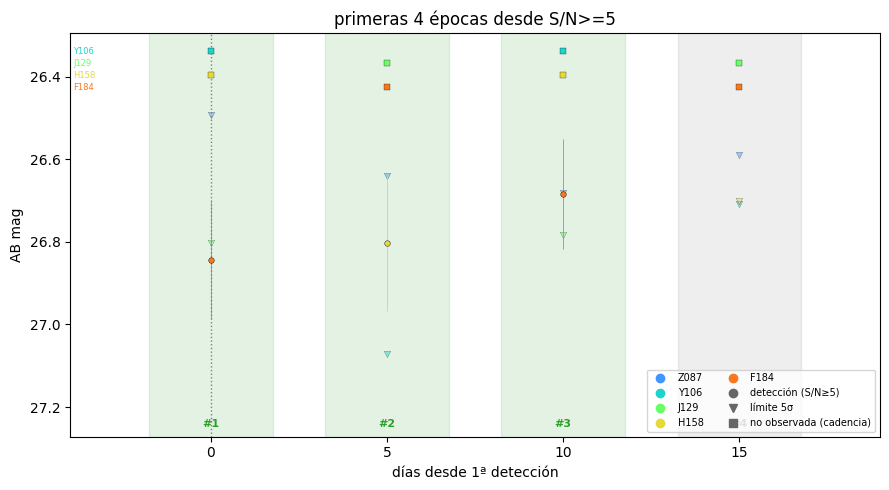

,days_since_detection,band,mag_true,mag_err,snr,detected
413,0.0,F184,26.844168,0.142454,7.621415,True
250,0.0,J129,27.697519,0.494803,2.194208,False
11,0.0,Z087,34.300804,288.037269,0.003769,False
332,5.0,H158,26.803368,0.163809,6.627831,True
169,5.0,Y106,29.524546,2.078634,0.522314,False
12,5.0,Z087,33.829517,163.139600,0.006655,False
414,10.0,F184,26.683706,0.132545,8.191168,True
251,10.0,J129,27.568130,0.447209,2.427726,False
13,10.0,Z087,33.588455,125.656266,0.008640,False
333,15.0,H158,26.741205,0.225140,4.822326,False


In [5]:
# La selección "primera detección -> N épocas" vive en roman_photometry (misma regla que el pipeline
# y el dataloader). Aquí solo se le agrega el plot con zoom + numeración de épocas, en days_since_detection.
from roman_photometry import first_epochs_since_detection as select_first_epochs


def first_epochs_since_detection(photometry, number=4, plot=True):
    """Primeras `number` ÉPOCAS DE OBSERVACIÓN (visitas, cada 5 d) desde la primera detección S/N>=5
    en cualquier banda (regla en roman_photometry.first_epochs_since_detection, eje 'days_since_detection').
    Por construcción la 1ª época cae en days_since_detection=0. Una visita SIN ninguna detección igual
    cuenta como época. El plot hace zoom a esa ventana y sombrea + numera las épocas (#1..#number)."""
    window = select_first_epochs(photometry, number=number, time_column="days_since_detection")
    if len(window) == 0:
        print("Sin detección S/N>=5: el objeto nunca supera el umbral (todo límites superiores).")
        if plot:
            plot_lightcurve_with_error(photometry, title="sin detección S/N>=5")
        return window
    epoch_times = np.sort(window["days_since_detection"].unique())
    if plot:
        figure, ax = plt.subplots(figsize=(9, 5))
        plot_lightcurve_with_error(photometry, title=f"primeras {number} épocas desde S/N>=5", ax=ax)
        # Zoom ajustado: solo la ventana de las `number` épocas + medio paso de cadencia a cada lado.
        pad = BASE_CADENCE_DAYS * 0.8
        x_low, x_high = epoch_times.min() - pad, epoch_times.max() + pad
        ax.set_xlim(x_low, x_high)
        in_window = photometry[(photometry["days_since_detection"] >= x_low)
                               & (photometry["days_since_detection"] <= x_high)]
        shown_mag = pd.concat([in_window.loc[in_window["detected"], "mag_observed"],
                               in_window.loc[~in_window["detected"], "mag_limit_5sigma"]])
        if len(shown_mag):
            margin = max(0.2, 0.1 * (shown_mag.max() - shown_mag.min()))
            ax.set_ylim(shown_mag.max() + margin, shown_mag.min() - margin)  # eje invertido
        # Sombrear y numerar cada época seleccionada; verde = tiene detección, gris = sin detección.
        for order, epoch in enumerate(epoch_times, start=1):
            has_detection = bool(window[(window["days_since_detection"] == epoch) & window["detected"]].shape[0])
            ax.axvspan(epoch - BASE_CADENCE_DAYS * 0.35, epoch + BASE_CADENCE_DAYS * 0.35,
                       color="tab:green" if has_detection else "0.5", alpha=0.13, zorder=0)
            ax.text(epoch, 0.02, f"#{order}", transform=ax.get_xaxis_transform(),
                    ha="center", va="bottom", fontsize=8, fontweight="bold",
                    color="tab:green" if has_detection else "0.4")
        plt.tight_layout()
        plt.show()
    return window


early_window = first_epochs_since_detection(photometry, number=4, plot=True)
early_window[["days_since_detection", "band", "mag_true", "mag_err", "snr", "detected"]]


## Validación final — detection limits vs la tabla de referencia Roman WFI

La tabla oficial de Roman WFI da la **profundidad 5σ por filtro** (S/N=5) a 57 s y 1 hr, medida en
**apertura de 2 px para fuentes puntuales**. Reproducimos esos números con nuestra receta para confirmar
que `zeropoint` + sky + NEA + read noise (eq. 9) son consistentes.

Calculamos **dos** límites por banda:

- **apertura 2 px** — misma definición que la tabla ⇒ debería caer **sobre** los valores de referencia
  (valida zeropoint, sky y read noise);
- **NEA / óptimo** — lo que realmente usa el pipeline ⇒ ~0.2–0.5 mag **más profundo** (la extracción
  óptima siempre gana sobre una apertura fija).

El campo se fija a **ELAIS-N1** (baja zodiacal) para igualar la condición de la tabla, independiente del
campo aleatorio de la corrida. Lectura de resultados: un offset **uniforme** en todas las bandas apunta a
la suposición de zodiacal/fecha; un **outlier** en una sola banda apunta al throughput/thermal de esa banda.


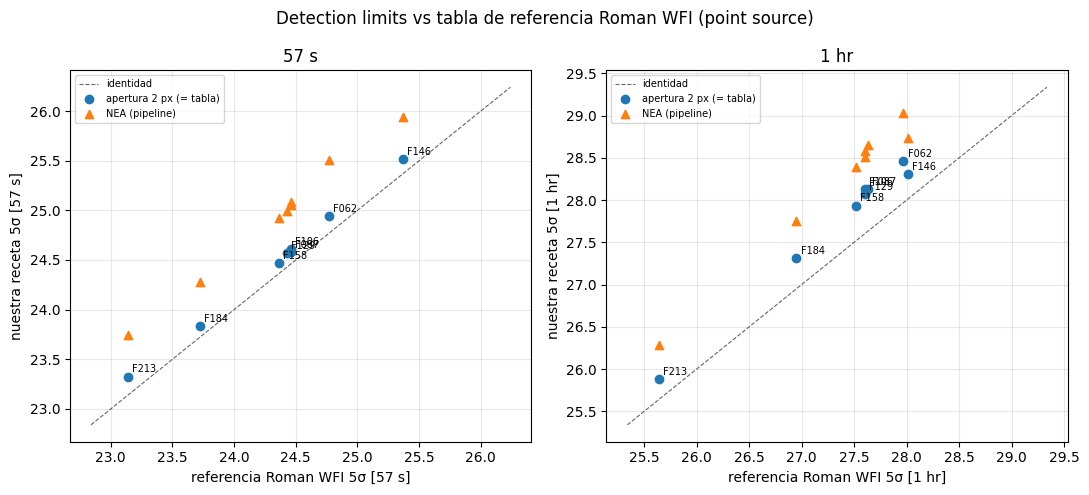

apertura 2px - referencia:  mediana Δ = +0.213 mag (rms 0.158)


,band,ref_57s,ap_57s,d_57s,ref_1hr,ap_1hr,d_1hr,nea_57s,nea_1hr
filter,,,,,,,,,
F062,R062,24.77,24.94,0.17,27.97,28.46,0.49,25.51,29.04
F087,Z087,24.46,24.58,0.12,27.63,28.13,0.50,25.09,28.65
F106,Y106,24.46,24.61,0.15,27.60,28.13,0.53,25.06,28.58
F129,J129,24.43,24.57,0.14,27.60,28.07,0.47,25.00,28.51
F158,H158,24.36,24.47,0.11,27.52,27.94,0.42,24.93,28.39
F184,F184,23.72,23.83,0.11,26.95,27.31,0.36,24.28,27.75
F213,K213,23.14,23.33,0.19,25.64,25.88,0.24,23.74,26.29
F146,W146,25.37,25.51,0.14,28.01,28.30,0.29,25.94,28.73


In [6]:
# Tabla de referencia Roman WFI, 5σ point source (apertura 2 px). filtro_tabla -> (banda galsim, 1hr, 57s).
REFERENCE_5SIGMA_POINT = {
    "F062": ("R062", 27.97, 24.77), "F087": ("Z087", 27.63, 24.46),
    "F106": ("Y106", 27.60, 24.46), "F129": ("J129", 27.60, 24.43),
    "F158": ("H158", 27.52, 24.36), "F184": ("F184", 26.95, 23.72),
    "F213": ("K213", 25.64, 23.14), "F146": ("W146", 28.01, 25.37),
}
VALIDATION_FIELD = galsim.CelestialCoord(HLTDS_FIELD_CENTER["ELAIS-N1"][0] * galsim.degrees,
                                         HLTDS_FIELD_CENTER["ELAIS-N1"][1] * galsim.degrees)
ALL_ROMAN_BANDPASSES = roman.getBandpasses()


def limiting_magnitude_aperture_nea(band, exposure, world_pos, snr=SNR_DETECTION):
    """5σ limiting AB mag de una fuente puntual a `exposure` s en `world_pos`. Devuelve (apertura, nea):
    - apertura: S/N en apertura de 2 px (igual que la tabla de referencia), via el PSF de getPSF;
    - nea     : S/N óptimo pesado por NEA (lo que usa el pipeline), con el NEA de Table 3 (PSF_NEA_PIX).
    K213/W146 no están en Table 3 -> para esas dos se usa la NEA del PSF de galsim como fallback."""
    bandpass = ALL_ROMAN_BANDPASSES[band]
    sky_level = roman.getSkyLevel(bandpass, world_pos=world_pos, exptime=exposure) * roman.pixel_scale ** 2
    read_noise = read_noise_electrons(exposure)
    background_per_pixel = (sky_level + roman.thermal_backgrounds[band] * exposure
                            + roman.dark_current * exposure + read_noise ** 2)

    psf = roman.getPSF(1, band, wavelength=bandpass.effective_wavelength,
                       pupil_bin=8).drawImage(scale=roman.pixel_scale, nx=64, ny=64).array
    psf = psf / psf.sum()
    grid_y, grid_x = np.indices(psf.shape)
    center = (psf.shape[0] - 1) / 2.0
    radius_pixels = np.hypot(grid_x - center, grid_y - center)
    aperture = radius_pixels <= 2.0
    encircled_fraction = psf[aperture].sum()
    aperture_pixels = int(aperture.sum())
    noise_equivalent_area = PSF_NEA_PIX.get(band, 1.0 / np.sum(psf ** 2))

    def limiting_mag(signal_fraction, effective_pixels):
        # SNR = (s·F) / sqrt(s·F + n·bkg) = snr  ->  cuadrática en (s·F)
        background = effective_pixels * background_per_pixel
        collected = 0.5 * (snr ** 2 + np.sqrt(snr ** 4 + 4 * snr ** 2 * background))
        flux_total = collected / signal_fraction
        rate = flux_total / (exposure * COLLECTING_AREA_CM2)
        return bandpass.zeropoint - 2.5 * np.log10(rate)

    return limiting_mag(encircled_fraction, aperture_pixels), limiting_mag(1.0, noise_equivalent_area)


def build_limit_comparison(world_pos=VALIDATION_FIELD):
    rows = []
    for table_filter, (band, reference_1hr, reference_57s) in REFERENCE_5SIGMA_POINT.items():
        aperture_1hr, nea_1hr = limiting_magnitude_aperture_nea(band, 3600.0, world_pos)
        aperture_57s, nea_57s = limiting_magnitude_aperture_nea(band, 57.0, world_pos)
        rows.append({
            "filter": table_filter, "band": band,
            "ref_57s": reference_57s, "ap_57s": aperture_57s, "d_57s": aperture_57s - reference_57s,
            "ref_1hr": reference_1hr, "ap_1hr": aperture_1hr, "d_1hr": aperture_1hr - reference_1hr,
            "nea_57s": nea_57s, "nea_1hr": nea_1hr,
        })
    return pd.DataFrame(rows).set_index("filter")


def plot_limit_comparison(comparison):
    figure, axes = plt.subplots(1, 2, figsize=(11, 5))
    for axis, label, reference_column, ours_column, nea_column in [
            (axes[0], "57 s", "ref_57s", "ap_57s", "nea_57s"),
            (axes[1], "1 hr", "ref_1hr", "ap_1hr", "nea_1hr")]:
        low = min(comparison[reference_column].min(), comparison[nea_column].min()) - 0.3
        high = max(comparison[reference_column].max(), comparison[nea_column].max()) + 0.3
        axis.plot([low, high], [low, high], "k--", lw=0.8, alpha=0.6, label="identidad")
        axis.scatter(comparison[reference_column], comparison[ours_column],
                     color="tab:blue", zorder=3, label="apertura 2 px (= tabla)")
        axis.scatter(comparison[reference_column], comparison[nea_column],
                     color="tab:orange", marker="^", zorder=3, label="NEA (pipeline)")
        for table_filter, row in comparison.iterrows():
            axis.annotate(table_filter, (row[reference_column], row[ours_column]),
                          fontsize=7, xytext=(3, 3), textcoords="offset points")
        axis.set_xlabel(f"referencia Roman WFI 5σ [{label}]")
        axis.set_ylabel(f"nuestra receta 5σ [{label}]")
        axis.set_title(label)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=7, loc="upper left")
    figure.suptitle("Detection limits vs tabla de referencia Roman WFI (point source)")
    plt.tight_layout()
    plt.show()


limit_comparison = build_limit_comparison()
plot_limit_comparison(limit_comparison)
print(f"apertura 2px - referencia:  mediana Δ = {limit_comparison[['d_57s', 'd_1hr']].stack().median():+.3f} mag "
      f"(rms {limit_comparison[['d_57s', 'd_1hr']].stack().std():.3f})")
limit_comparison.round(2)


## Roman WFI Characteristics Used in Simulations

Características por banda y tier que entran a la receta de ruido de este notebook, derivadas de
`galsim.roman` a **nuestros** tiempos de exposición del HLTDS (`EXPOSURE_TIME_BY_TIER`). Es la tabla
para el paper: documenta cada término del modelo de error y la profundidad alcanzada, de forma trazable.
Las unidades van en el segundo renglón del header (MultiIndex de columnas).

- **exp** — tiempo de exposición total por época del tier (s).
- **PSF_NEA** — número equivalente de píxeles de la PSF (pix), fijo por banda.
- **σ_read** — read noise efectivo (e⁻/pix) a esa exposición (up-the-ramp, eq. 9): baja con `t` hacia el piso de 5 e⁻.
- **σ²_thermal** — tasa de fondo térmico (e⁻/s/pix), `roman.thermal_backgrounds`.
- **σ²_zodi** — tasa de luz zodiacal (e⁻/s/pix), `getSkyLevel` en el campo ELAIS-N1.
- **σ²_dark** — corriente de oscuridad (e⁻/s/pix), `roman.dark_current`.
- **σ_sky** — ruido de fondo acumulado: `sqrt((σ²_zodi+σ²_thermal+σ²_dark)·t)` (e⁻ = ADU con gain 1).
- **ZP_AVG** — zeropoint instrumental en e⁻ totales: `zp_galsim + 2.5·log10(collecting_area) + 2.5·log10(t)` (mag).
- **m_lim_5σ** — magnitud límite AB a S/N = 5 con extracción NEA (la del pipeline), a la exposición del tier (mag).

El error fotométrico de cada época sale de combinar estas columnas con la ecuación CCD
`σ²(F) = F_fuente + NEA·(sky + thermal·t + dark·t + read²)`, más el jitter de zeropoint de 0.15 mag
que absorbe la variación FOV del NEA.


In [7]:
# Tabla de características Roman WFI usadas en nuestras simulaciones: cada término del modelo de ruido más
# la magnitud límite 5sigma, por banda y tier, a los tiempos de exposición del HLTDS (EXPOSURE_TIME_BY_TIER).
# Campo ELAIS-N1 para la zodiacal. Las unidades van en el segundo nivel del header (MultiIndex de columnas).
# delta_zp convierte el zeropoint galsim (fotones/cm^2/s) a e- totales (zeropoint instrumental).
DELTA_ZEROPOINT = 2.5 * np.log10(roman.collecting_area)

# Decimales por columna para el export a LaTeX (to_latex usa 6 por defecto -> ceros de relleno feos).
COLUMN_DECIMALS = {
    ("exp", "s"): 0, ("PSF_NEA", "pix"): 3, ("sigma_read", "e-/pix"): 2,
    ("sigma2_thermal", "e-/s/pix"): 3, ("sigma2_zodi", "e-/s/pix"): 3, ("sigma2_dark", "e-/s/pix"): 3,
    ("sigma_sky", "ADU/pix"): 2, ("ZP_AVG", "mag"): 2, ("m_lim_5sigma", "mag"): 2,
}


def build_characteristics_table(world_pos=VALIDATION_FIELD):
    """Características por (tier, banda) de la receta de ruido de este notebook, derivadas de galsim.roman
    a los tiempos de EXPOSURE_TIME_BY_TIER: NEA, read, thermal, zodi, dark, sky, zeropoint instrumental y
    magnitud límite 5sigma (extracción NEA, la del pipeline)."""
    rows = []
    for tier, exposures in EXPOSURE_TIME_BY_TIER.items():
        for band, exposure in exposures.items():
            bandpass = ALL_ROMAN_BANDPASSES[band]
            zodi_rate = roman.getSkyLevel(bandpass, world_pos=world_pos, exptime=1.0) * roman.pixel_scale ** 2
            thermal_rate = roman.thermal_backgrounds[band]
            dark_rate = roman.dark_current
            sigma_read = read_noise_electrons(exposure)
            noise_equivalent_area = PSF_NEA_PIX[band]
            background_per_pixel = (zodi_rate + thermal_rate + dark_rate) * exposure + sigma_read ** 2
            sigma_sky = np.sqrt((zodi_rate + thermal_rate + dark_rate) * exposure)
            noise_floor_variance = noise_equivalent_area * background_per_pixel
            # Flujo de fuente que da SNR = 5 sobre ese fondo (cuadrática SNR = F/sqrt(F + noise_floor)).
            limiting_flux = 0.5 * (SNR_DETECTION ** 2
                                   + np.sqrt(SNR_DETECTION ** 4 + 4 * SNR_DETECTION ** 2 * noise_floor_variance))
            limiting_magnitude = bandpass.zeropoint - 2.5 * np.log10(limiting_flux / (exposure * roman.collecting_area))
            zeropoint_average = bandpass.zeropoint + DELTA_ZEROPOINT + 2.5 * np.log10(exposure)
            rows.append({
                ("tier", ""): tier, ("filter", ""): band, ("exp", "s"): exposure,
                ("PSF_NEA", "pix"): noise_equivalent_area, ("sigma_read", "e-/pix"): sigma_read,
                ("sigma2_thermal", "e-/s/pix"): thermal_rate, ("sigma2_zodi", "e-/s/pix"): zodi_rate,
                ("sigma2_dark", "e-/s/pix"): dark_rate, ("sigma_sky", "ADU/pix"): sigma_sky,
                ("ZP_AVG", "mag"): zeropoint_average, ("m_lim_5sigma", "mag"): limiting_magnitude,
            })
    table = pd.DataFrame(rows).set_index([("tier", ""), ("filter", "")])
    table.index.names = ["tier", "filter"]
    table.columns = pd.MultiIndex.from_tuples(table.columns)
    return table


def characteristics_to_latex(table):
    """LaTeX listo para el paper: formatea cada columna a su precisión (COLUMN_DECIMALS) para evitar los
    ceros de relleno que mete to_latex por defecto. exp queda como entero."""
    formatted = table.copy()
    for column, decimals in COLUMN_DECIMALS.items():
        formatted[column] = table[column].map(lambda value: f"{value:.{decimals}f}")
    return formatted.to_latex(multirow=True, column_format="ll" + "r" * table.shape[1])


roman_wfi_characteristics = build_characteristics_table()
print(characteristics_to_latex(roman_wfi_characteristics))
roman_wfi_characteristics.round(3)


\begin{tabular}{llrrrrrrrrr}
\toprule
 &  & exp & PSF_NEA & sigma_read & sigma2_thermal & sigma2_zodi & sigma2_dark & sigma_sky & ZP_AVG & m_lim_5sigma \\
 &  & s & pix & e-/pix & e-/s/pix & e-/s/pix & e-/s/pix & ADU/pix & mag & mag \\
tier & filter &  &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{wide} & R062 & 60 & 5.575 & 12.87 & 0.000 & 0.328 & 0.015 & 4.54 & 31.18 & 25.58 \\
 & Z087 & 85 & 6.695 & 11.28 & 0.000 & 0.299 & 0.015 & 5.17 & 31.22 & 25.63 \\
 & Y106 & 95 & 7.895 & 10.83 & 0.000 & 0.326 & 0.015 & 5.69 & 31.40 & 25.74 \\
 & J129 & 152 & 9.210 & 9.17 & 0.000 & 0.332 & 0.015 & 7.26 & 31.93 & 26.23 \\
 & H158 & 294 & 11.140 & 7.49 & 0.040 & 0.325 & 0.015 & 10.58 & 32.68 & 26.78 \\
\cline{1-11}
\multirow[t]{5}{*}{deep} & Z087 & 193 & 6.695 & 8.48 & 0.000 & 0.299 & 0.015 & 7.79 & 32.12 & 26.59 \\
 & Y106 & 294 & 7.895 & 7.49 & 0.000 & 0.326 & 0.015 & 10.01 & 32.63 & 26.94 \\
 & J129 & 307 & 9.210 & 7.40 & 0.000 & 0.332 & 0.015 & 10.31 & 32.69 & 26.91 \\
 & H158 & 420 

exp PSF_NEA sigma_read sigma2_thermal sigma2_zodi sigma2_dark  \
                  s     pix     e-/pix       e-/s/pix    e-/s/pix    e-/s/pix   
tier filter                                                                     
wide R062      60.0   5.575     12.870           0.00       0.328       0.015   
     Z087      85.0   6.695     11.282           0.00       0.299       0.015   
     Y106      95.0   7.895     10.826           0.00       0.326       0.015   
     J129     152.0   9.210      9.167           0.00       0.332       0.015   
     H158     294.0  11.140      7.491           0.04       0.325       0.015   
deep Z087     193.0   6.695      8.479           0.00       0.299       0.015   
     Y106     294.0   7.895      7.491           0.00       0.326       0.015   
     J129     307.0   9.210      7.404           0.00       0.332       0.015   
     H158     420.0  11.140      6.850           0.04       0.325       0.015   
     F184    1636.0  16.335      5.540           0.17       0.185       0.015   

            sigma_sky  ZP_AVG m_lim_5sigma  
              ADU/pix     mag          mag  
tier filter                                 
wide R062       4.535  31.179       25.577  
     Z087       5.170  31.225       25.627  
     Y106       5.690  31.405       25.738  
     J129       7.258  31.931       26.232  
     H158      10.576  32.682       26.782  
deep Z087       7.790  32.115       26.592  
     Y106      10.010  32.632       26.943  
     J129      10.314  32.695       26.912  
     H158      12.641  33.069       27.063  
     F184      24.609  34.094       27.299